In [2]:
%pip install -q optuna
%pip install -q --upgrade prophet
%pip install -q --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
sys.path.append('C:\\Users\\migue\\FinTech-ML-Portfolio\\2_scripts\\')
from local_trainer import trainer
from MultiLocalTrainer import Mtrainer
from multiprocessing import Pool
from datetime import datetime, timedelta

In [4]:
def ladata(ticker, FHi='2021-01-01', FHe=""):
    ticker = ticker.upper()
    ticker_id = ticker.lower().replace('.', '').replace('-', '')
    if FHe == "":
        FHe = datetime.today().strftime('%Y-%m-%d')

    #DatAss = yf.download(ticker, start=FHi, end=FHe, interval='1d', auto_adjust=True)
    df = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']
    df_prophet = df.reset_index().copy()
    df_prophet['ds'] = df.index
    df_prophet['y'] = df_prophet[ticker]
    df_prophet = df_prophet[['ds', 'y']]

    return df_prophet

[*********************100%***********************]  1 of 1 completed


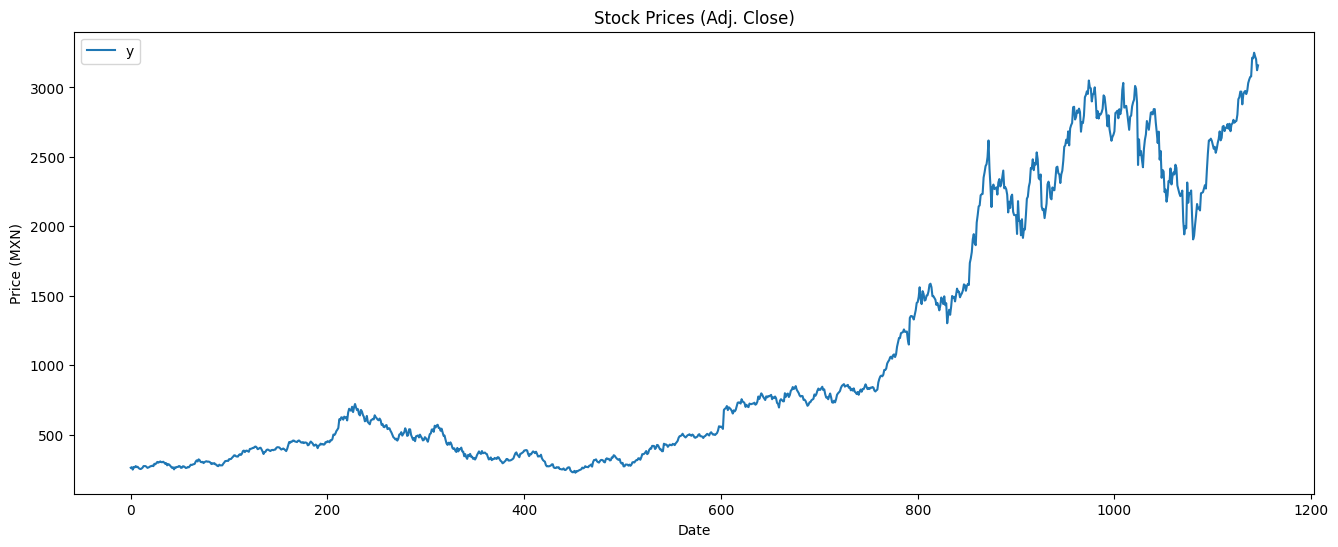

Ticker,ds,y
1142,2025-07-17,3249.600098
1143,2025-07-18,3223.870117
1144,2025-07-21,3203.290039
1145,2025-07-22,3123.719971
1146,2025-07-23,3158.360107


In [5]:
DatAss = ladata('NVDA.MX')

DatAss['y'].plot(figsize=(16,6), title='Stock Prices (Adj. Close)')
plt.ylabel('Price (MXN)')
plt.xlabel('Date')
plt.legend()
plt.show()

DatAss.tail()

In [ ]:
def launch_batch(horizontes):
    for hori in horizontes:
        Mtrainer('NVDA.MX', DatAss, trials=200, hori=hori, peri=2, graficar=False, guardar=False)


horiz = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
with Pool(processes=20) as pool:
    pool.map(launch_batch, horiz)